# Movie Rental Data Warehouse — Full ETL & Analysis Notebook


1. **Extract** — Load all required tables from the `sakila` OLTP database
2. **Transform** — Clean and reshape data into dimension and fact tables
3. **Load** — Write the warehouse tables into `film_dw`
4. **Analyse** — Run business queries against the warehouse

The warehouse follows a **star schema** with two fact tables:

| Fact Table | Grain | Key Measures |
|---|---|---|
| `fact_rental` | One row per rental transaction | rental_count, rental_duration, late_return_days |
| `fact_payment` | One row per payment transaction | payment_amount, payment_count |

Shared dimension tables: `dim_date`, `dim_customer`, `dim_film`, `dim_store`, `dim_staff`, `dim_location`

---

## Business Questions Answered

| # | Question |
|---|---|
| Q1 | Which films are rented most frequently? |
| Q2 | Which stores generate the highest revenue? |
| Q3 | Which customers spend the most? |
| Q4 | How does revenue change by month and year? |
| Q5 | Which films have the most late returns? |
| Q6 | Which cities generate the most rental activity? |
| Q7 | Which staff members process the most revenue? |
| Q8 | Which film categories are most popular? |
| Q9 | What is the average rental duration by film rating? |
| Q10 | Which films generate the highest revenue? |


## 1. Install Required Libraries

In [1]:
%pip install pandas numpy sqlalchemy pymysql matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

## 3. Database Connections

Connects to:
- **Source:** `sakila` — the OLTP operational database
- **Target:** `film_dw` — the Data Warehouse


In [3]:
MYSQL_USER     = "root"
MYSQL_PASSWORD = "1111"
MYSQL_HOST     = "127.0.0.1"
MYSQL_PORT     = 3306
SOURCE_DB      = "sakila"
TARGET_DB      = "film_dw"

server_engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}"
)

with server_engine.connect() as conn:
    conn.execute(text(f"CREATE DATABASE IF NOT EXISTS {TARGET_DB}"))
    conn.commit()

source_engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{SOURCE_DB}"
)
dw_engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{TARGET_DB}"
)

print(f"Source : {SOURCE_DB}")
print(f"Target : {TARGET_DB}")
print("Connections created successfully.")

Source : sakila
Target : film_dw
Connections created successfully.


## 4. Test Connections

In [4]:
with source_engine.connect() as conn:
    rental_count  = conn.execute(text("SELECT COUNT(*) FROM rental")).fetchone()[0]
    payment_count = conn.execute(text("SELECT COUNT(*) FROM payment")).fetchone()[0]

print("Sakila connected successfully.")
print(f"  rental rows  : {rental_count:,}")
print(f"  payment rows : {payment_count:,}")

Sakila connected successfully.
  rental rows  : 16,044
  payment rows : 16,044


---
# Extract Phase

Extract all required source tables from the `sakila` OLTP database.

| Source Table | Purpose |
|---|---|
| rental | Core rental transactions |
| payment | Payment records |
| customer | Customer details |
| film | Film catalogue |
| inventory | Links films to stores |
| store | Store details |
| staff | Staff details |
| address | Address lookup |
| city | City lookup |
| country | Country lookup |
| category | Film category lookup |
| film_category | Film-to-category mapping |
| language | Language lookup |
| actor | Actor details |
| film_actor | Film-to-actor mapping |


In [5]:
tables = [
    "rental", "payment", "customer", "film", "inventory",
    "store", "staff", "address", "city", "country",
    "category", "film_category", "language", "actor", "film_actor"
]

data = {}
for table in tables:
    data[table] = pd.read_sql(f"SELECT * FROM {table}", source_engine)
    print(f"  Loaded {table:<20} {data[table].shape}")

rental        = data["rental"]
payment       = data["payment"]
customer      = data["customer"]
film          = data["film"]
inventory     = data["inventory"]
store         = data["store"]
staff         = data["staff"]
address       = data["address"]
city          = data["city"]
country       = data["country"]
category      = data["category"]
film_category = data["film_category"]
language      = data["language"]
actor         = data["actor"]
film_actor    = data["film_actor"]

print("\nExtract phase completed.")

  Loaded rental               (16044, 7)
  Loaded payment              (16044, 7)
  Loaded customer             (599, 9)
  Loaded film                 (1000, 13)
  Loaded inventory            (4581, 4)
  Loaded store                (2, 4)
  Loaded staff                (2, 11)
  Loaded address              (603, 9)
  Loaded city                 (600, 4)
  Loaded country              (109, 3)
  Loaded category             (16, 3)
  Loaded film_category        (1000, 3)
  Loaded language             (6, 3)
  Loaded actor                (200, 4)
  Loaded film_actor           (5462, 3)

Extract phase completed.


---
# Transform Phase

## 5. Data Cleaning


In [6]:
# Check duplicates
print("=== Duplicate Rows ===")
for name in data:
    dups = data[name].duplicated().sum()
    print(f"  {name:<20} {dups} duplicates")

=== Duplicate Rows ===
  rental               0 duplicates
  payment              0 duplicates
  customer             0 duplicates
  film                 0 duplicates
  inventory            0 duplicates
  store                0 duplicates
  staff                0 duplicates
  address              0 duplicates
  city                 0 duplicates
  country              0 duplicates
  category             0 duplicates
  film_category        0 duplicates
  language             0 duplicates
  actor                0 duplicates
  film_actor           0 duplicates


In [7]:
# Check nulls
print("=== Null Values ===")
for name in data:
    nulls = data[name].isnull().sum()
    if nulls.any():
        print(f"\n{name}")
        print(nulls[nulls > 0])

=== Null Values ===

rental
return_date    183
dtype: int64

film
original_language_id    1000
dtype: int64

staff
picture     1
password    1
dtype: int64

address
address2    4
dtype: int64


### Missing Values Explanation

| Column | Reason | Handling |
|---|---|---|
| `rental.return_date` | Film not yet returned | Mapped to unknown date key |
| `film.original_language_id` | Not used in DW | Ignored |
| `staff.picture`, `staff.password` | Not needed in DW | Ignored |
| `address.address2` | Optional field | Filled with "Unknown" |


In [8]:
# Remove duplicates
for name in data:
    before = len(data[name])
    data[name] = data[name].drop_duplicates()
    after = len(data[name])
    if before != after:
        print(f"{name}: removed {before - after} duplicate rows")

rental        = data["rental"]
payment       = data["payment"]
customer      = data["customer"]
film          = data["film"]
inventory     = data["inventory"]
store         = data["store"]
staff         = data["staff"]
address       = data["address"]
city          = data["city"]
country       = data["country"]
category      = data["category"]
film_category = data["film_category"]
language      = data["language"]
actor         = data["actor"]
film_actor    = data["film_actor"]

print("Data cleaning completed.")

Data cleaning completed.


## 6. Create dim_date

In [9]:
all_dates = pd.concat([
    pd.to_datetime(rental["rental_date"],   errors="coerce"),
    pd.to_datetime(rental["return_date"],   errors="coerce"),
    pd.to_datetime(payment["payment_date"], errors="coerce")
]).dropna().drop_duplicates()

dim_date = pd.DataFrame({"full_date": all_dates})
dim_date["full_date"] = pd.to_datetime(dim_date["full_date"]).dt.date
dim_date = dim_date.drop_duplicates()

dim_date["date_key"]    = pd.to_datetime(dim_date["full_date"]).dt.strftime("%Y%m%d").astype(int)
dim_date["day"]         = pd.to_datetime(dim_date["full_date"]).dt.day
dim_date["month"]       = pd.to_datetime(dim_date["full_date"]).dt.month
dim_date["month_name"]  = pd.to_datetime(dim_date["full_date"]).dt.month_name()
dim_date["quarter_num"] = pd.to_datetime(dim_date["full_date"]).dt.quarter
dim_date["year"]        = pd.to_datetime(dim_date["full_date"]).dt.year
dim_date["weekday_name"]= pd.to_datetime(dim_date["full_date"]).dt.day_name()
dim_date["weekend_flag"]= pd.to_datetime(dim_date["full_date"]).dt.dayofweek.apply(
    lambda x: "Y" if x >= 5 else "N"
)

unknown_date = pd.DataFrame({
    "date_key": [19000101], "full_date": [pd.to_datetime("1900-01-01").date()],
    "day": [1], "month": [1], "month_name": ["January"],
    "quarter_num": [1], "year": [1900], "weekday_name": ["Monday"], "weekend_flag": ["N"]
})

dim_date = pd.concat([unknown_date, dim_date], ignore_index=True)
dim_date = dim_date[[
    "date_key", "full_date", "day", "month", "month_name",
    "quarter_num", "year", "weekday_name", "weekend_flag"
]].drop_duplicates("date_key")

display(dim_date.head())
print("dim_date rows:", len(dim_date))

,date_key,full_date,day,month,month_name,quarter_num,year,weekday_name,weekend_flag
0,19000101,1900-01-01,1,1,January,1,1900,Monday,N
1,20050524,2005-05-24,24,5,May,2,2005,Tuesday,N
2,20050525,2005-05-25,25,5,May,2,2005,Wednesday,N
3,20050526,2005-05-26,26,5,May,2,2005,Thursday,N
4,20050527,2005-05-27,27,5,May,2,2005,Friday,N


dim_date rows: 91


## 7. Create dim_location

In [10]:
location_full = address.merge(city, on="city_id", how="left")
location_full = location_full.merge(country, on="country_id", how="left")

dim_location = location_full[[
    "address_id", "city", "country", "district"
]].drop_duplicates().reset_index(drop=True)

dim_location.insert(0, "location_key", range(1, len(dim_location) + 1))

display(dim_location.head())
print("dim_location rows:", len(dim_location))

,location_key,address_id,city,country,district
0,1,1,Lethbridge,Canada,Alberta
1,2,2,Woodridge,Australia,QLD
2,3,3,Lethbridge,Canada,Alberta
3,4,4,Woodridge,Australia,QLD
4,5,5,Sasebo,Japan,Nagasaki


dim_location rows: 603


## 8. Create dim_customer

In [11]:
dim_customer = customer.copy()
dim_customer["full_name"] = (
    dim_customer["first_name"].fillna("") + " " + dim_customer["last_name"].fillna("")
).str.strip()
dim_customer["email"] = dim_customer["email"].fillna("Unknown")

dim_customer = dim_customer[[
    "customer_id", "full_name", "email", "active", "create_date"
]].rename(columns={"active": "active_status"}).drop_duplicates().reset_index(drop=True)

dim_customer.insert(0, "customer_key", range(1, len(dim_customer) + 1))

display(dim_customer.head())
print("dim_customer rows:", len(dim_customer))

,customer_key,customer_id,full_name,email,active_status,create_date
0,1,1,MARY SMITH,MARY.SMITH@sakilacustomer.org,1,2006-02-14 22:04:36
1,2,2,PATRICIA JOHNSON,PATRICIA.JOHNSON@sakilacustomer.org,1,2006-02-14 22:04:36
2,3,3,LINDA WILLIAMS,LINDA.WILLIAMS@sakilacustomer.org,1,2006-02-14 22:04:36
3,4,4,BARBARA JONES,BARBARA.JONES@sakilacustomer.org,1,2006-02-14 22:04:36
4,5,5,ELIZABETH BROWN,ELIZABETH.BROWN@sakilacustomer.org,1,2006-02-14 22:04:36


dim_customer rows: 599


## 9. Create dim_store

In [12]:
manager_info = staff.copy()
manager_info["manager_name"] = (
    manager_info["first_name"].fillna("") + " " + manager_info["last_name"].fillna("")
).str.strip()
manager_info = manager_info[["staff_id", "manager_name"]]

dim_store = store.merge(
    dim_location[["location_key", "address_id"]], on="address_id", how="left"
).merge(
    manager_info, left_on="manager_staff_id", right_on="staff_id", how="left"
)

dim_store = dim_store[[
    "store_id", "manager_name", "location_key"
]].drop_duplicates().reset_index(drop=True)

dim_store.insert(0, "store_key", range(1, len(dim_store) + 1))

display(dim_store.head())
print("dim_store rows:", len(dim_store))

,store_key,store_id,manager_name,location_key
0,1,1,Mike Hillyer,1
1,2,2,Jon Stephens,2


dim_store rows: 2


## 10. Create dim_staff

In [13]:
dim_staff = staff.copy()
dim_staff["full_name"] = (
    dim_staff["first_name"].fillna("") + " " + dim_staff["last_name"].fillna("")
).str.strip()
dim_staff["email"] = dim_staff["email"].fillna("Unknown")

dim_staff = dim_staff[[
    "staff_id", "full_name", "email", "active", "store_id"
]].rename(columns={"active": "active_status"}).drop_duplicates().reset_index(drop=True)

dim_staff.insert(0, "staff_key", range(1, len(dim_staff) + 1))

display(dim_staff.head())
print("dim_staff rows:", len(dim_staff))

,staff_key,staff_id,full_name,email,active_status,store_id
0,1,1,Mike Hillyer,Mike.Hillyer@sakilastaff.com,1,1
1,2,2,Jon Stephens,Jon.Stephens@sakilastaff.com,1,2


dim_staff rows: 2


## 11. Create dim_film

In [14]:
# Primary category per film
film_cat = film_category.merge(category[["category_id", "name"]], on="category_id", how="left")
film_cat = film_cat.groupby("film_id")["name"].first().reset_index().rename(columns={"name": "category_name"})

# Language
film_lang = film.merge(language[["language_id", "name"]], on="language_id", how="left").rename(columns={"name": "language_name"})

dim_film = film_lang.merge(film_cat, on="film_id", how="left")

dim_film = dim_film[[
    "film_id", "title", "description", "release_year",
    "rental_duration", "rental_rate", "length",
    "rating", "language_name", "category_name"
]].drop_duplicates("film_id").reset_index(drop=True)

dim_film.insert(0, "film_key", range(1, len(dim_film) + 1))

display(dim_film.head())
print("dim_film rows:", len(dim_film))

,film_key,film_id,title,description,release_year,rental_duration,rental_rate,length,rating,language_name,category_name
0,1,1,ACADEMY DINOSAUR,A Epic Drama of a Feminist And a Mad Scientist...,2006,6,0.99,86,PG,English,Documentary
1,2,2,ACE GOLDFINGER,A Astounding Epistle of a Database Administrat...,2006,3,4.99,48,G,English,Horror
2,3,3,ADAPTATION HOLES,A Astounding Reflection of a Lumberjack And a ...,2006,7,2.99,50,NC-17,English,Documentary
3,4,4,AFFAIR PREJUDICE,A Fanciful Documentary of a Frisbee And a Lumb...,2006,5,2.99,117,G,English,Horror
4,5,5,AFRICAN EGG,A Fast-Paced Documentary of a Pastry Chef And ...,2006,6,2.99,130,G,English,Family


dim_film rows: 1000


## 12. Create fact_rental

**Grain:** One row per rental transaction.


In [ ]:
fact_rental = rental.merge(
    inventory[["inventory_id", "film_id", "store_id"]], on="inventory_id", how="left"
)

# Date keys
fact_rental["date_key"] = pd.to_datetime(
    fact_rental["rental_date"], errors="coerce"
).dt.strftime("%Y%m%d").astype(int)

fact_rental["return_date_key"] = pd.to_datetime(
    fact_rental["return_date"], errors="coerce"
).dt.strftime("%Y%m%d").fillna("19000101").astype(int)

# Rental duration
fact_rental["actual_duration"] = (
    pd.to_datetime(fact_rental["return_date"], errors="coerce")
    - pd.to_datetime(fact_rental["rental_date"], errors="coerce")
).dt.days

fact_rental["rental_duration"] = fact_rental["actual_duration"].fillna(-1).astype(int)
fact_rental["rental_count"] = 1

# Surrogate keys
fact_rental = fact_rental.merge(dim_customer[["customer_key", "customer_id"]], on="customer_id", how="left")
fact_rental = fact_rental.merge(dim_film[["film_key", "film_id", "rental_duration"]], on="film_id", how="left", suffixes=("", "_expected"))
fact_rental = fact_rental.merge(dim_store[["store_key", "store_id"]], on="store_id", how="left")
fact_rental = fact_rental.merge(dim_staff[["staff_key", "staff_id"]], on="staff_id", how="left")

# Get location via customer → address
customer_address = customer[["customer_id", "address_id"]]
fact_rental = fact_rental.merge(customer_address, on="customer_id", how="left")
fact_rental = fact_rental.merge(dim_location[["location_key", "address_id"]], on="address_id", how="left")

# Late return
fact_rental["late_return_days"] = fact_rental.apply(
    lambda row: max(row["rental_duration"] - row["rental_duration_expected"], 0)
    if row["rental_duration"] >= 0 else 0, axis=1
)

fact_rental_final = fact_rental[[
    "rental_id", "date_key", "customer_key", "film_key",
    "store_key", "staff_key", "location_key",
    "rental_count", "rental_duration", "late_return_days"
]].copy()

fact_rental_final.insert(0, "rental_fact_key", range(1, len(fact_rental_final) + 1))

display(fact_rental_final.head())
print("fact_rental rows:", len(fact_rental_final))

,rental_fact_key,rental_id,date_key,customer_key,film_key,store_key,staff_key,location_key,rental_count,rental_duration,late_return_days
0,1,1,20050524,130,80,1,1,134,1,1,0
1,2,2,20050524,459,333,2,1,463,1,3,0
2,3,3,20050524,408,373,2,1,412,1,7,0
3,4,4,20050524,333,535,1,2,337,1,9,3
4,5,5,20050524,222,450,2,1,226,1,8,3


fact_rental rows: 16044


## 13. Create fact_payment

**Grain:** One row per payment transaction.


In [18]:
fact_payment = payment.copy()

fact_payment["payment_date_key"] = pd.to_datetime(
    fact_payment["payment_date"], errors="coerce"
).dt.strftime("%Y%m%d").astype(int)

fact_payment["payment_count"] = 1

fact_payment = fact_payment.merge(rental[["rental_id", "inventory_id"]], on="rental_id", how="left")
fact_payment = fact_payment.merge(inventory[["inventory_id", "store_id", "film_id"]], on="inventory_id", how="left")
fact_payment = fact_payment.merge(dim_customer[["customer_key", "customer_id"]], on="customer_id", how="left")
fact_payment = fact_payment.merge(dim_staff[["staff_key", "staff_id"]], on="staff_id", how="left")
fact_payment = fact_payment.merge(dim_store[["store_key", "store_id"]], on="store_id", how="left")
fact_payment = fact_payment.merge(dim_film[["film_key", "film_id"]], on="film_id", how="left")

# Get location via customer → address
customer_address = customer[["customer_id", "address_id"]]
fact_payment = fact_payment.merge(customer_address, on="customer_id", how="left")
fact_payment = fact_payment.merge(dim_location[["location_key", "address_id"]], on="address_id", how="left")

fact_payment_final = fact_payment[[
    "payment_id", "payment_date_key", "customer_key", "film_key",
    "store_key", "staff_key", "location_key",
    "amount", "payment_count"
]].rename(columns={"amount": "payment_amount"}).copy()

fact_payment_final.insert(0, "payment_fact_key", range(1, len(fact_payment_final) + 1))

display(fact_payment_final.head())
print("fact_payment rows:", len(fact_payment_final))

,payment_fact_key,payment_id,payment_date_key,customer_key,film_key,store_key,staff_key,location_key,payment_amount,payment_count
0,1,1,20050525,1,663,2,1,5,2.99,1
1,2,2,20050528,1,875,2,1,5,0.99,1
2,3,3,20050615,1,611,1,1,5,5.99,1
3,4,4,20050615,1,228,2,2,5,0.99,1
4,5,5,20050615,1,308,1,2,5,9.99,1


fact_payment rows: 16044


---
## 14. Data Quality Checks

Validate all surrogate keys before loading.


In [19]:
print("=== Data Quality Checks ===")

checks = {
    "fact_rental — customer_key" : fact_rental_final["customer_key"].isnull().sum(),
    "fact_rental — film_key"     : fact_rental_final["film_key"].isnull().sum(),
    "fact_rental — store_key"    : fact_rental_final["store_key"].isnull().sum(),
    "fact_rental — staff_key"    : fact_rental_final["staff_key"].isnull().sum(),
    "fact_payment — customer_key": fact_payment_final["customer_key"].isnull().sum(),
    "fact_payment — staff_key"   : fact_payment_final["staff_key"].isnull().sum(),
    "fact_payment — store_key"   : fact_payment_final["store_key"].isnull().sum(),
    "fact_payment — film_key"    : fact_payment_final["film_key"].isnull().sum(),
    "fact_payment — negative amt": (fact_payment_final["payment_amount"] < 0).sum(),
}

all_passed = True
for check, count in checks.items():
    status = "PASS" if count == 0 else "FAIL"
    if count > 0:
        all_passed = False
    print(f"  [{status}] {check:<40} {count} issues")

print()
if all_passed:
    print("All data quality checks passed. Ready to load.")
else:
    print("Some checks failed. Review before loading.")

=== Data Quality Checks ===
  [PASS] fact_rental — customer_key               0 issues
  [PASS] fact_rental — film_key                   0 issues
  [PASS] fact_rental — store_key                  0 issues
  [PASS] fact_rental — staff_key                  0 issues
  [PASS] fact_payment — customer_key              0 issues
  [PASS] fact_payment — staff_key                 0 issues
  [PASS] fact_payment — store_key                 0 issues
  [PASS] fact_payment — film_key                  0 issues
  [PASS] fact_payment — negative amt              0 issues

All data quality checks passed. Ready to load.


---
# Load Phase

Dimension tables are loaded **before** fact tables because facts reference dimension surrogate keys.

**Loading order:**
1. dim_date
2. dim_location
3. dim_customer
4. dim_film
5. dim_store
6. dim_staff
7. fact_rental
8. fact_payment


In [25]:
with dw_engine.connect() as conn:
    conn.execute(text("SET FOREIGN_KEY_CHECKS = 0"))
    for table in ["fact_rental", "fact_payment", "dim_date", "dim_location",
                  "dim_customer", "dim_film", "dim_store", "dim_staff"]:
        conn.execute(text(f"DROP TABLE IF EXISTS {table}"))
    conn.execute(text("SET FOREIGN_KEY_CHECKS = 1"))
    conn.commit()

print("All tables dropped. Ready to reload.")

All tables dropped. Ready to reload.


In [26]:
# Disable foreign key checks so we can replace tables freely
with dw_engine.connect() as conn:
    conn.execute(text("SET FOREIGN_KEY_CHECKS = 0"))
    conn.commit()

# Load dimensions first
dim_date.to_sql("dim_date",         dw_engine, if_exists="replace", index=False)
dim_location.to_sql("dim_location", dw_engine, if_exists="replace", index=False)
dim_customer.to_sql("dim_customer", dw_engine, if_exists="replace", index=False)
dim_film.to_sql("dim_film",         dw_engine, if_exists="replace", index=False)
dim_store.to_sql("dim_store",       dw_engine, if_exists="replace", index=False)
dim_staff.to_sql("dim_staff",       dw_engine, if_exists="replace", index=False)

# Load facts after dimensions
fact_rental_final.to_sql("fact_rental",   dw_engine, if_exists="replace", index=False)
fact_payment_final.to_sql("fact_payment", dw_engine, if_exists="replace", index=False)

# Re-enable foreign key checks
with dw_engine.connect() as conn:
    conn.execute(text("SET FOREIGN_KEY_CHECKS = 1"))
    conn.commit()

print("Tables loaded successfully.")

# Add primary keys
pk_sql = [
    "ALTER TABLE dim_date     ADD PRIMARY KEY (date_key)",
    "ALTER TABLE dim_location ADD PRIMARY KEY (location_key)",
    "ALTER TABLE dim_customer ADD PRIMARY KEY (customer_key)",
    "ALTER TABLE dim_film     ADD PRIMARY KEY (film_key)",
    "ALTER TABLE dim_store    ADD PRIMARY KEY (store_key)",
    "ALTER TABLE dim_staff    ADD PRIMARY KEY (staff_key)",
    "ALTER TABLE fact_rental  ADD PRIMARY KEY (rental_fact_key)",
    "ALTER TABLE fact_payment ADD PRIMARY KEY (payment_fact_key)",
]

with dw_engine.connect() as conn:
    for sql in pk_sql:
        try:
            conn.execute(text(sql))
        except Exception as e:
            print(f"Skipped: {e}")
    conn.commit()

print("Load phase completed successfully.")
print("Primary keys added.")

Tables loaded successfully.
Load phase completed successfully.
Primary keys added.


## 15. Verify Loaded Tables

In [27]:
print("=== Row Counts in film_dw ===")
for table in ["dim_date", "dim_location", "dim_customer", "dim_film",
              "dim_store", "dim_staff", "fact_rental", "fact_payment"]:
    count = pd.read_sql(f"SELECT COUNT(*) AS cnt FROM {table}", dw_engine).iloc[0, 0]
    print(f"  {table:<25} {count:>8,} rows")

=== Row Counts in film_dw ===
  dim_date                        91 rows
  dim_location                   603 rows
  dim_customer                   599 rows
  dim_film                     1,000 rows
  dim_store                        2 rows
  dim_staff                        2 rows
  fact_rental                 16,044 rows
  fact_payment                16,044 rows


---
# Analysis Phase

Business queries against the `film_dw` data warehouse.


### Q1 — Top 10 Most Rented Films
**Business question:** Which films are rented most frequently?


In [28]:
query1 = '''
SELECT
    f.title,
    f.category_name,
    f.rating,
    SUM(fr.rental_count) AS total_rentals
FROM fact_rental fr
JOIN dim_film f ON fr.film_key = f.film_key
GROUP BY f.title, f.category_name, f.rating
ORDER BY total_rentals DESC
LIMIT 10;
'''
df1 = pd.read_sql(query1, dw_engine)
print("=== Q1: Top 10 Most Rented Films ===")
display(df1)

=== Q1: Top 10 Most Rented Films ===


,title,category_name,rating,total_rentals
0,BUCKET BROTHERHOOD,Travel,PG,34.0
1,ROCKETEER MOTHER,Foreign,PG-13,33.0
2,RIDGEMONT SUBMARINE,New,PG-13,32.0
3,SCALAWAG DUCK,Music,NC-17,32.0
4,GRIT CLOCKWORK,Games,PG,32.0
5,FORWARD TEMPLE,Games,NC-17,32.0
6,JUGGLER HARDLY,Animation,PG-13,32.0
7,TIMBERLAND SKY,Classics,G,31.0
8,ZORRO ARK,Comedy,NC-17,31.0
9,NETWORK PEAK,Family,PG-13,31.0


### Q2 — Revenue by Store
**Business question:** Which stores generate the highest revenue?


In [29]:
query2 = '''
SELECT
    s.store_id,
    s.manager_name,
    SUM(fp.payment_amount)     AS total_revenue,
    COUNT(fp.payment_fact_key) AS total_payments
FROM fact_payment fp
JOIN dim_store s ON fp.store_key = s.store_key
GROUP BY s.store_id, s.manager_name
ORDER BY total_revenue DESC;
'''
df2 = pd.read_sql(query2, dw_engine)
print("=== Q2: Revenue by Store ===")
display(df2)

=== Q2: Revenue by Store ===


,store_id,manager_name,total_revenue,total_payments
0,2,Jon Stephens,33726.77,8121
1,1,Mike Hillyer,33679.79,7923


### Q3 — Top 10 Customers by Total Spending
**Business question:** Which customers generate the highest revenue?


In [30]:
query3 = '''
SELECT
    c.full_name,
    c.email,
    SUM(fp.payment_amount)     AS total_spent,
    COUNT(fp.payment_fact_key) AS total_payments
FROM fact_payment fp
JOIN dim_customer c ON fp.customer_key = c.customer_key
GROUP BY c.full_name, c.email
ORDER BY total_spent DESC
LIMIT 10;
'''
df3 = pd.read_sql(query3, dw_engine)
print("=== Q3: Top 10 Customers by Spending ===")
display(df3)

=== Q3: Top 10 Customers by Spending ===


,full_name,email,total_spent,total_payments
0,KARL SEAL,KARL.SEAL@sakilacustomer.org,221.55,45
1,ELEANOR HUNT,ELEANOR.HUNT@sakilacustomer.org,216.54,46
2,CLARA SHAW,CLARA.SHAW@sakilacustomer.org,195.58,42
3,RHONDA KENNEDY,RHONDA.KENNEDY@sakilacustomer.org,194.61,39
4,MARION SNYDER,MARION.SNYDER@sakilacustomer.org,194.61,39
5,TOMMY COLLAZO,TOMMY.COLLAZO@sakilacustomer.org,186.62,38
6,WESLEY BULL,WESLEY.BULL@sakilacustomer.org,177.60,40
7,TIM CARY,TIM.CARY@sakilacustomer.org,175.61,39
8,MARCIA DEAN,MARCIA.DEAN@sakilacustomer.org,175.58,42
9,ANA BRADLEY,ANA.BRADLEY@sakilacustomer.org,174.66,34


### Q4 — Monthly Revenue Trend
**Business question:** How does revenue change by month and year?


=== Q4: Monthly Revenue Trend ===


,year,month,month_name,total_revenue,total_payments
0,2005,5,May,4823.44,1156
1,2005,6,June,9629.89,2311
2,2005,7,July,28368.91,6709
3,2005,8,August,24070.14,5686
4,2006,2,February,514.18,182


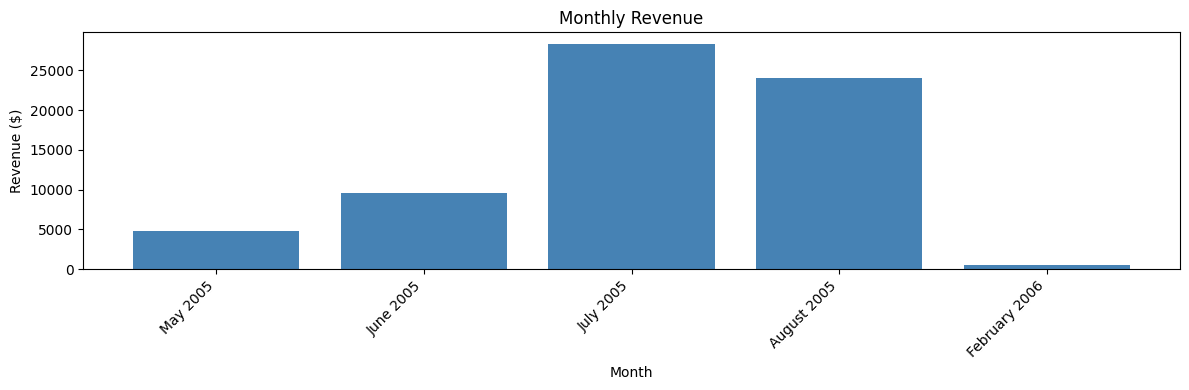

In [31]:
query4 = '''
SELECT
    d.year,
    d.month,
    d.month_name,
    SUM(fp.payment_amount)     AS total_revenue,
    COUNT(fp.payment_fact_key) AS total_payments
FROM fact_payment fp
JOIN dim_date d ON fp.payment_date_key = d.date_key
GROUP BY d.year, d.month, d.month_name
ORDER BY d.year, d.month;
'''
df4 = pd.read_sql(query4, dw_engine)
print("=== Q4: Monthly Revenue Trend ===")
display(df4)

fig, ax = plt.subplots(figsize=(12, 4))
labels = df4["month_name"] + " " + df4["year"].astype(str)
ax.bar(labels, df4["total_revenue"], color="steelblue")
ax.set_title("Monthly Revenue")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue ($)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Q5 — Top 10 Films with Most Late Returns
**Business question:** Which films are returned late most often?


In [32]:
query5 = '''
SELECT
    f.title,
    f.category_name,
    COUNT(*)                  AS late_return_count,
    AVG(fr.late_return_days)  AS avg_late_days
FROM fact_rental fr
JOIN dim_film f ON fr.film_key = f.film_key
WHERE fr.late_return_days > 0
GROUP BY f.title, f.category_name
ORDER BY late_return_count DESC
LIMIT 10;
'''
df5 = pd.read_sql(query5, dw_engine)
df5["avg_late_days"] = df5["avg_late_days"].round(2)
print("=== Q5: Top 10 Films with Most Late Returns ===")
display(df5)

=== Q5: Top 10 Films with Most Late Returns ===


,title,category_name,late_return_count,avg_late_days
0,RIDGEMONT SUBMARINE,New,24,3.62
1,BUTTERFLY CHOCOLAT,New,23,3.35
2,TELEGRAPH VOYAGE,Music,22,3.77
3,TIMBERLAND SKY,Classics,21,3.90
4,CHANCE RESURRECTION,Sports,20,2.45
5,GRIT CLOCKWORK,Games,20,3.40
6,ROCKETEER MOTHER,Foreign,20,3.75
7,ENGLISH BULWORTH,Sci-Fi,20,3.05
8,SATURDAY LAMBS,Sports,19,2.84
9,PRINCESS GIANT,Documentary,19,2.95


### Q6 — Top 10 Cities by Rental Activity
**Business question:** Which cities generate the most rental activity?


In [33]:
query6 = '''
SELECT
    l.city,
    l.country,
    SUM(fr.rental_count) AS total_rentals
FROM fact_rental fr
JOIN dim_location l ON fr.location_key = l.location_key
GROUP BY l.city, l.country
ORDER BY total_rentals DESC
LIMIT 10;
'''
df6 = pd.read_sql(query6, dw_engine)
print("=== Q6: Top 10 Cities by Rental Activity ===")
display(df6)

=== Q6: Top 10 Cities by Rental Activity ===


,city,country,total_rentals
0,Aurora,United States,50.0
1,London,United Kingdom,48.0
2,Saint-Denis,Réunion,46.0
3,Cape Coral,United States,45.0
4,Tanza,Philippines,42.0
5,Molodetšno,Belarus,42.0
6,Changhwa,Taiwan,41.0
7,Changzhou,China,40.0
8,Ourense (Orense),Spain,40.0
9,Bijapur,India,39.0


### Q7 — Staff Revenue Performance
**Business question:** Which staff members process the most revenue?


In [34]:
query7 = '''
SELECT
    s.full_name,
    s.email,
    SUM(fp.payment_amount)     AS total_revenue,
    COUNT(fp.payment_fact_key) AS total_payments
FROM fact_payment fp
JOIN dim_staff s ON fp.staff_key = s.staff_key
GROUP BY s.full_name, s.email
ORDER BY total_revenue DESC;
'''
df7 = pd.read_sql(query7, dw_engine)
print("=== Q7: Staff Revenue Performance ===")
display(df7)

=== Q7: Staff Revenue Performance ===


,full_name,email,total_revenue,total_payments
0,Jon Stephens,Jon.Stephens@sakilastaff.com,33924.06,7990
1,Mike Hillyer,Mike.Hillyer@sakilastaff.com,33482.50,8054


### Q8 — Most Popular Film Categories
**Business question:** Which film categories are rented the most?


In [35]:
query8 = '''
SELECT
    f.category_name,
    SUM(fr.rental_count) AS total_rentals
FROM fact_rental fr
JOIN dim_film f ON fr.film_key = f.film_key
GROUP BY f.category_name
ORDER BY total_rentals DESC
LIMIT 15;
'''
df8 = pd.read_sql(query8, dw_engine)
print("=== Q8: Most Popular Film Categories ===")
display(df8)

=== Q8: Most Popular Film Categories ===


,category_name,total_rentals
0,Sports,1179.0
1,Animation,1166.0
2,Action,1112.0
3,Sci-Fi,1101.0
4,Family,1096.0
5,Drama,1060.0
6,Documentary,1050.0
7,Foreign,1033.0
8,Games,969.0
9,Children,945.0


### Q9 — Average Rental Duration by Film Rating
**Business question:** What is the average rental duration for different film ratings?


In [36]:
query9 = '''
SELECT
    f.rating,
    COUNT(fr.rental_fact_key)  AS total_rentals,
    AVG(fr.rental_duration)    AS avg_duration_days,
    MAX(fr.rental_duration)    AS max_duration_days
FROM fact_rental fr
JOIN dim_film f ON fr.film_key = f.film_key
WHERE fr.rental_duration > 0
GROUP BY f.rating
ORDER BY avg_duration_days DESC;
'''
df9 = pd.read_sql(query9, dw_engine)
df9["avg_duration_days"] = df9["avg_duration_days"].round(2)
print("=== Q9: Average Rental Duration by Film Rating ===")
display(df9)

=== Q9: Average Rental Duration by Film Rating ===


,rating,total_rentals,avg_duration_days,max_duration_days
0,PG-13,3350,4.84,9
1,G,2598,4.80,9
2,NC-17,3079,4.78,9
3,PG,3005,4.74,9
4,R,2983,4.74,9


### Q10 — Top 10 Films by Revenue
**Business question:** Which films generate the highest revenue?


In [37]:
query10 = '''
SELECT
    f.title,
    f.category_name,
    f.rating,
    SUM(fp.payment_amount)     AS total_revenue,
    COUNT(fp.payment_fact_key) AS total_payments
FROM fact_payment fp
JOIN dim_film f ON fp.film_key = f.film_key
GROUP BY f.title, f.category_name, f.rating
ORDER BY total_revenue DESC
LIMIT 10;
'''
df10 = pd.read_sql(query10, dw_engine)
print("=== Q10: Top 10 Films by Revenue ===")
display(df10)

=== Q10: Top 10 Films by Revenue ===


,title,category_name,rating,total_revenue,total_payments
0,TELEGRAPH VOYAGE,Music,PG,231.73,27
1,WIFE TURN,Documentary,NC-17,223.69,31
2,ZORRO ARK,Comedy,NC-17,214.69,31
3,GOODFELLAS SALUTE,Sci-Fi,PG,209.69,31
4,SATURDAY LAMBS,Sports,G,204.72,28
5,TITANS JERK,Sci-Fi,PG,201.71,29
6,TORQUE BOUND,Drama,G,198.72,27
7,HARRY IDAHO,Drama,PG-13,195.70,30
8,INNOCENT USUAL,Foreign,PG-13,191.74,26
9,HUSTLER PARTY,Comedy,NC-17,190.78,22
